<a href="https://colab.research.google.com/github/hassnainsvtti-collab/AI-with-SVTTI/blob/main/Module3_Machine_Learning_Simple_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 3 — Machine Learning
## Dev Valley Software House & Incubation Centre, Gujranwala

---

**Topics covered in this notebook:**

| # | Topic | Type |
|---|-------|------|
| 1 | Linear Regression | Supervised — predicts a number |
| 2 | Classification (Logistic Regression) | Supervised — predicts a category |
| 3 | Decision Tree | Supervised — rule-based decisions |
| 4 | Random Forest | Supervised — many trees together |
| 5 | SVM | Supervised — finds the best boundary |
| 6 | K-Means Clustering | Unsupervised — groups without labels |
| 7 | Model Comparison | All models side by side |

> All datasets are built into Scikit-learn — no file downloads needed.

---
## Step 0 — Import Libraries
Run this cell first. Every section below depends on it.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris, load_diabetes, load_breast_cancer, make_blobs

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score, mean_squared_error, r2_score, confusion_matrix

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans

print('All libraries imported successfully!')

All libraries imported successfully!


---
## Step 1 — Load the Datasets

We use three famous datasets that come built into Scikit-learn:

| Dataset | Used For | What it contains |
|---------|----------|------------------|
| **Diabetes** | Regression | Patient measurements → disease score |
| **Iris** | Classification, Decision Tree, SVM | Flower measurements → species |
| **Breast Cancer** | Random Forest | Tumour measurements → malignant/benign |

In [ ]:
# --- Diabetes dataset ---
diabetes    = load_diabetes()
df_diabetes = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df_diabetes['target'] = diabetes.target

# --- Iris dataset ---
iris    = load_iris()
df_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
df_iris['species'] = iris.target

# --- Breast Cancer dataset ---
cancer    = load_breast_cancer()
df_cancer = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df_cancer['target'] = cancer.target


Diabetes dataset: (442, 11)
Iris dataset    : (150, 5) | Classes: ['setosa', 'versicolor', 'virginica']
Cancer dataset  : (569, 31) | Classes: ['malignant', 'benign']


---
## Section 1 — Linear Regression

**What it does:** Predicts a continuous number.

**Example:** Given patient measurements (BMI, blood pressure) → predict diabetes disease score.

**Formula:** `prediction = w1*x1 + w2*x2 + ... + b`

The model learns the best values of `w` (weights) and `b` (bias) from training data.

**Evaluation metrics:**
- **RMSE** — average error in the same units as the target (lower = better)
- **R²** — how much of the pattern the model captured (1.0 = perfect)

RMSE : 53.77  (how far off predictions are on average)
R²   : 0.45  (1.0 = perfect, 0.0 = useless)


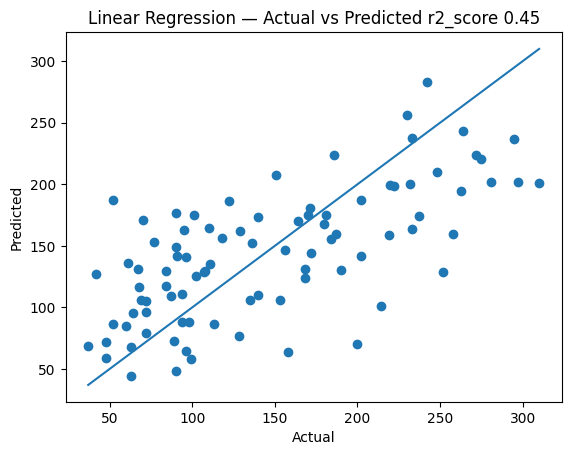

In [ ]:
# --- Prepare data ---
X = df_diabetes[['bmi', 'bp', 's5']]   # 3 input features
y = df_diabetes['target']              # what we want to predict
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
model = LinearRegression()
model.fit(X_train_scaled, y_train)
X_test_scaled
y_pred = model.predict(X_test_scaled)
abc=mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2   = r2_score(y_test, y_pred)

print(f'RMSE : {rmse:.2f}  (how far off predictions are on average)')
print(f'R²   : {r2:.2f}  (1.0 = perfect, 0.0 = useless)')

# # --- Plot: Actual vs Predicted ---


plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Linear Regression — Actual vs Predicted r2_score 0.45')
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])

---
## Section 2 — Classification (Logistic Regression)

**What it does:** Predicts a category/label.

**Example:** Given flower measurements → predict species (Setosa / Versicolor / Virginica).

**Key difference from Linear Regression:**
- Linear Regression → outputs a number
- Logistic Regression → outputs a probability → converts to a class label

**Evaluation:**
- **Accuracy** — percentage of correct predictions
- **Confusion Matrix** — shows which classes the model confuses

Accuracy: 92.1%


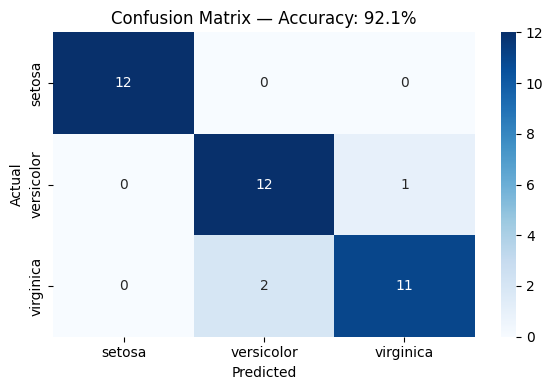

Each row = actual class | Each column = predicted class
Numbers on the diagonal = correct predictions


In [ ]:
# --- Prepare data ---
X = df_iris[iris.feature_names]
y = df_iris['species']

# --- Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# --- Scale ---
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# --- Train ---
model = LogisticRegression(max_iter=200, random_state=42)
model.fit(X_train_s, y_train)

# --- Predict and evaluate ---
y_pred   = model.predict(X_test_s)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy*100:.1f}%')

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title(f'Confusion Matrix — Accuracy: {accuracy*100:.1f}%')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print('Each row = actual class | Each column = predicted class')
print('Numbers on the diagonal = correct predictions')

---
## Section 3 — Decision Tree

**What it does:** Makes decisions by asking a series of YES/NO questions, like a flowchart.

**Example question the tree learns:**
```
Is petal length < 2.5 cm?
    YES → Setosa
    NO  → Is petal width < 1.8 cm?
              YES → Versicolor
              NO  → Virginica
```

**Key concept — max_depth:**
- Too shallow → underfitting (misses patterns)
- Too deep → overfitting (memorises training data, fails on new data)
- Best → find the depth where test accuracy is highest

Depth     Train Acc   Test Acc
------------------------------
2             0.950      0.967
3             0.958      1.000
4             0.975      1.000
5             0.992      1.000

Best model accuracy: 100.0%

Decision rules the tree learned:
|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal length (cm) <= 4.75
|   |   |--- petal width (cm) <= 1.65
|   |   |   |--- class: 1
|   |   |--- petal width (cm) >  1.65
|   |   |   |--- class: 2
|   |--- petal length (cm) >  4.75
|   |   |--- petal width (cm) <= 1.75
|   |   |   |--- class: 1
|   |   |--- petal width (cm) >  1.75
|   |   |   |--- class: 2



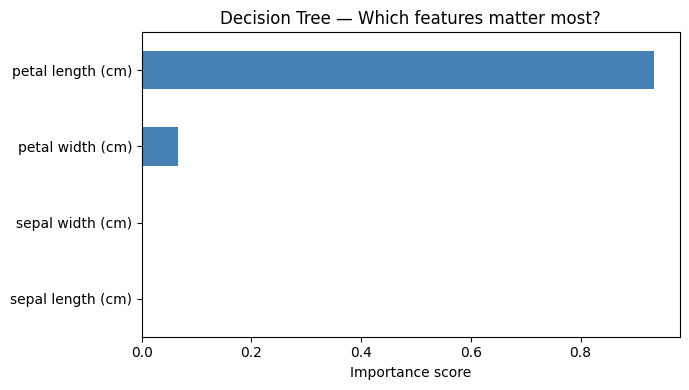

In [ ]:
# --- Prepare data ---
X = df_iris[iris.feature_names]
y = df_iris['species']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Try different depths to find the best one ---
print(f'{"Depth":<8} {"Train Acc":>10} {"Test Acc":>10}')
print('-' * 30)
for depth in [2, 3, 4, 5]:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)
    train_acc = dt.score(X_train, y_train)
    test_acc  = dt.score(X_test,  y_test)
    note = '  <- overfitting!' if (train_acc - test_acc) > 0.05 else ''
    print(f'{depth:<8} {train_acc:>10.3f} {test_acc:>10.3f}{note}')

# --- Train best model (depth=3) ---
best_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
best_tree.fit(X_train, y_train)

print(f'\nBest model accuracy: {best_tree.score(X_test, y_test)*100:.1f}%')

# --- Show the learned rules ---
print('\nDecision rules the tree learned:')
print(export_text(best_tree, feature_names=iris.feature_names))

# --- Feature importance ---
importance = pd.Series(best_tree.feature_importances_, index=iris.feature_names)
importance = importance.sort_values(ascending=True)

plt.figure(figsize=(7, 4))
importance.plot(kind='barh', color='steelblue')
plt.title('Decision Tree — Which features matter most?')
plt.xlabel('Importance score')
plt.tight_layout()
plt.show()

---
## Section 4 — Random Forest

**What it does:** Builds many Decision Trees and combines their votes.

**Why it is better than one tree:**
- One tree can overfit
- 100 trees each see random parts of the data → their errors cancel out → more accurate

**Analogy:** Asking 100 doctors instead of 1 → majority vote is more reliable.

**Key parameter:** `n_estimators` = number of trees (more trees = more stable, but slower)

Single Decision Tree accuracy : 91.2%
Random Forest accuracy        : 95.6%
Random Forest is almost always more accurate!


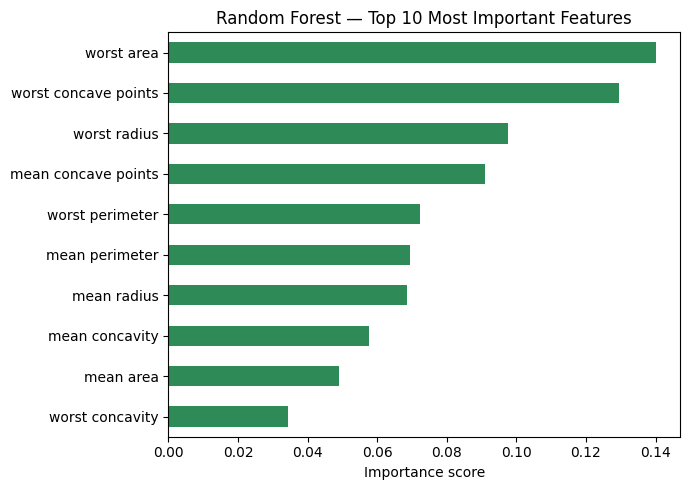

In [ ]:
# --- Prepare data ---
X = df_cancer.drop('target', axis=1)
y = df_cancer['target']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- Compare: single tree vs random forest ---
single_tree = DecisionTreeClassifier(random_state=42)
single_tree.fit(X_train, y_train)

forest = RandomForestClassifier(n_estimators=100, random_state=42)
forest.fit(X_train, y_train)

print(f'Single Decision Tree accuracy : {single_tree.score(X_test, y_test)*100:.1f}%')
print(f'Random Forest accuracy        : {forest.score(X_test, y_test)*100:.1f}%')
print('Random Forest is almost always more accurate!')

# --- Top 10 most important features ---
top10 = pd.Series(forest.feature_importances_, index=X.columns).nlargest(10).sort_values()

plt.figure(figsize=(7, 5))
top10.plot(kind='barh', color='seagreen')
plt.title('Random Forest — Top 10 Most Important Features')
plt.xlabel('Importance score')
plt.tight_layout()
plt.show()

---
## Section 5 — SVM (Support Vector Machine)

**What it does:** Finds the widest possible boundary (margin) between classes.

**Key idea:** The points closest to the boundary are called **support vectors** — they define the boundary.

**Kernels:**
- `linear` — straight line boundary
- `rbf` — curved boundary (works best in most cases)
- `poly` — polynomial curved boundary

> SVM needs feature scaling — always use StandardScaler before training SVM.

Kernel       Accuracy
----------------------
linear         100.0%
rbf             96.7%
poly            90.0%

Best SVM (rbf) accuracy       : 96.7%
Number of support vectors     : 47


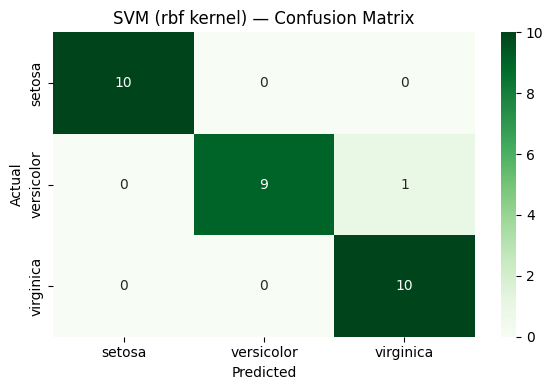

In [ ]:
# --- Prepare data ---
X = df_iris[iris.feature_names]
y = df_iris['species']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- Scale (required for SVM) ---
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# --- Compare kernels ---
print(f'{"Kernel":<10} {"Accuracy":>10}')
print('-' * 22)
for kernel in ['linear', 'rbf', 'poly']:
    svm = SVC(kernel=kernel, random_state=42)
    svm.fit(X_train_s, y_train)
    acc = svm.score(X_test_s, y_test)
    print(f'{kernel:<10} {acc*100:>9.1f}%')

# --- Train best model (rbf) ---
best_svm = SVC(kernel='rbf', random_state=42)
best_svm.fit(X_train_s, y_train)
y_pred = best_svm.predict(X_test_s)

print(f'\nBest SVM (rbf) accuracy       : {accuracy_score(y_test, y_pred)*100:.1f}%')
print(f'Number of support vectors     : {best_svm.support_vectors_.shape[0]}')

# --- Confusion matrix ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title('SVM (rbf kernel) — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

---
## Section 6 — K-Means Clustering

**What it does:** Groups data into K clusters — with NO labels, no correct answers.

**This is Unsupervised Learning** — the model finds hidden patterns on its own.

**How K-Means works:**
1. Place K random cluster centres (centroids)
2. Assign each point to the nearest centroid
3. Move each centroid to the average of its points
4. Repeat steps 2–3 until nothing changes

**How to choose K — the Elbow Method:**
Plot inertia (total distance) for K = 1, 2, 3 ... → the "elbow" in the curve is the best K.

Generated 300 data points with 4 natural clusters


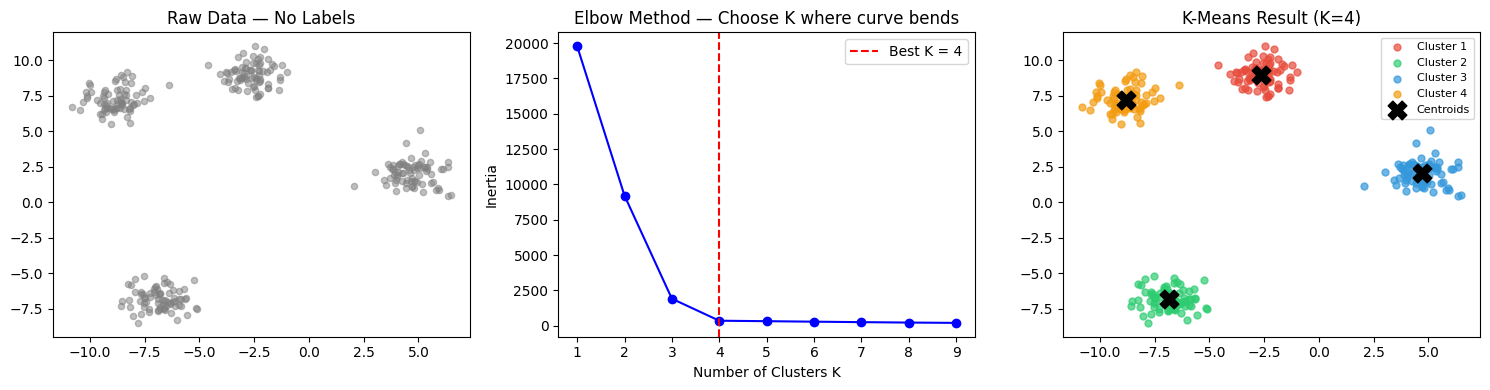

In [ ]:
# --- Generate data with 4 natural groups ---
X_blobs, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.8, random_state=42)
print(f'Generated {len(X_blobs)} data points with 4 natural clusters')

# --- Elbow Method: find the best K ---
inertias = []
for k in range(1, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_blobs)
    inertias.append(km.inertia_)

# --- Train final model with K=4 ---
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_blobs)

# --- Plot results ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Raw data (no labels)
axes[0].scatter(X_blobs[:, 0], X_blobs[:, 1], color='gray', alpha=0.5, s=20)
axes[0].set_title('Raw Data — No Labels')

# Elbow curve
axes[1].plot(range(1, 10), inertias, 'bo-')
axes[1].axvline(x=4, color='red', linestyle='--', label='Best K = 4')
axes[1].set_xlabel('Number of Clusters K')
axes[1].set_ylabel('Inertia')
axes[1].set_title('Elbow Method — Choose K where curve bends')
axes[1].legend()

# Clustered result
colors = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12']
for i in range(4):
    mask = labels == i
    axes[2].scatter(X_blobs[mask, 0], X_blobs[mask, 1],
                    color=colors[i], label=f'Cluster {i+1}', alpha=0.7, s=25)
axes[2].scatter(kmeans.cluster_centers_[:, 0],
                kmeans.cluster_centers_[:, 1],
                color='black', marker='X', s=180, zorder=5, label='Centroids')
axes[2].set_title('K-Means Result (K=4)')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## Section 7 — All Models Side by Side

Now we run all 4 classification models on the same Iris dataset and compare.

We use **5-fold Cross-Validation** instead of a single train/test split:
- The data is split into 5 equal parts
- The model trains on 4 parts and tests on 1 part — repeated 5 times
- Final score = average of all 5 test scores → more reliable than one split

Model                   Mean Accuracy    Std Dev
------------------------------------------------
Logistic Regression             96.0%  ±3.9%
Decision Tree                   97.3%  ±2.5%
Random Forest                   96.7%  ±2.1%
SVM (rbf)                       96.7%  ±2.1%


/tmp/ipykernel_3051/2385875583.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(cv_scores_all.values(), labels=cv_scores_all.keys(), patch_artist=True)


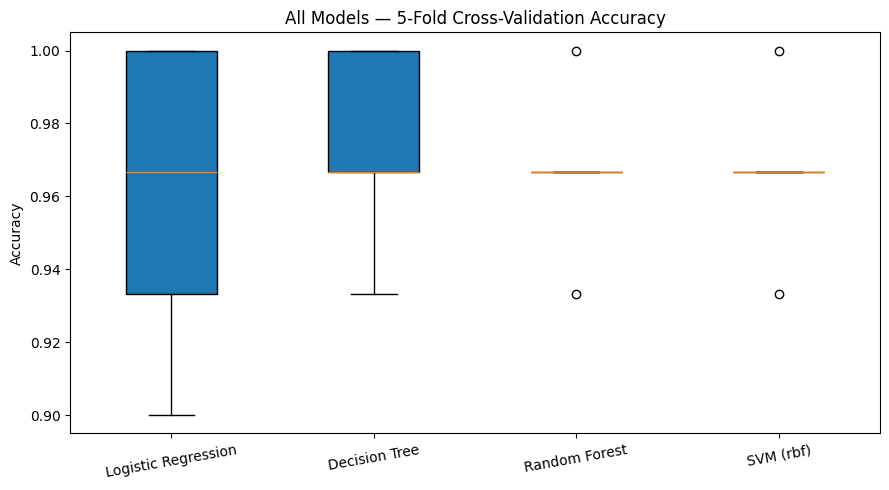

The box shows the spread across 5 folds.
A taller box = less consistent. Shorter box = more stable.


In [ ]:
# --- Prepare data ---
X = df_iris[iris.feature_names]
y = df_iris['species']

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- All models ---
models = {
    'Logistic Regression': LogisticRegression(max_iter=200, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=3, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM (rbf)':           SVC(kernel='rbf', random_state=42),
}

# --- Run cross-validation for each model ---
print(f'{"Model":<22} {"Mean Accuracy":>14} {"Std Dev":>10}')
print('-' * 48)

cv_scores_all = {}
for name, model in models.items():
    scores = cross_val_score(model, X_scaled, y, cv=5, scoring='accuracy')
    cv_scores_all[name] = scores
    print(f'{name:<22} {scores.mean()*100:>13.1f}%  ±{scores.std()*100:.1f}%')

# --- Box plot ---
plt.figure(figsize=(9, 5))
plt.boxplot(cv_scores_all.values(), labels=cv_scores_all.keys(), patch_artist=True)
plt.ylabel('Accuracy')
plt.title('All Models — 5-Fold Cross-Validation Accuracy')
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

print('The box shows the spread across 5 folds.')
print('A taller box = less consistent. Shorter box = more stable.')

---
## Summary — Module 3 Complete

| Algorithm | Type | Predicts | Dataset Used |
|-----------|------|----------|--------------|
| Linear Regression | Supervised | A number | Diabetes |
| Logistic Regression | Supervised | A category | Iris |
| Decision Tree | Supervised | A category (with rules) | Iris |
| Random Forest | Supervised | A category (many trees) | Breast Cancer |
| SVM | Supervised | A category (margin) | Iris |
| K-Means | Unsupervised | Groups (no labels) | Synthetic blobs |

---

**5 rules to always follow:**
1. Always split data into train and test before training
2. Always scale features before Logistic Regression and SVM
3. Use cross-validation for a reliable accuracy score
4. Check for overfitting — if train accuracy >> test accuracy, the model is memorising
5. Compare multiple models — there is no single best algorithm for every problem

---
**Next: Module 4 — Deep Learning (Neural Networks, TensorFlow, CNN, RNN)**